# Sesión 4

+ Vamos a estudiar un poquito como nos hacemos de datos a partir de APIs

## ¿Qué es una API?

+ API significa Application Programming Interface (Interfaz de Programación de Aplicaciones).... es un nombre muy poco afortunado.

+ Es un conjunto de reglas y protocolos que permite que dos sistemas o programas se comuniquen entre sí.

+ Es decir, tiene como objetivo la comunicación entre 2 o más sistemas.

+ Define qué solicitudes se pueden hacer, cómo hacerlas y qué tipo de respuesta se recibirá.

+ Funciona como un intermediario entre un cliente (por ejemplo, una app) y un servidor.

+ LO MÁS IMPORTANTE: Permite acceder a datos o funcionalidades sin necesidad de conocer la implementación interna del sistema, i.e. sólo está interesada en compartir lo que se debe compartir y no más.

+ En aplicaciones actuales es fundamental para la integración de servicios (por ejemplo, pagos, mapas, autenticación).

+ Generlmente utiliza protocolos como HTTP/HTTPS y formatos de datos como JSON o XML.... Afortunadamente la sesión pasada vimos un poquito de JSON.

+ Su popularidad se debe a que facilita la modularidad, reutilización y escalabilidad del software... Se enfoca en lo que se quiere compartir y no en todo.

+ En la que vamos a trabajar hoy es una de POKEMON

https://pokeapi.co/

+ Viendo esta página web, notamos que podamos extraer un montón de información sobre los pokemones y la tiene guardada en formato JSON

In [1]:
import requests # Es la es la estrella para mandar llamar a la API

# Cargué pandas porque eventualmente la vamos a usar para manipular dataframes
import pandas as pd

In [2]:
# Estamos emulando lo que hicimos en la página web al introducir en el browser la palabra "pikachu"
url = f"https://pokeapi.co/api/v2/pokemon/{"pikachu"}"

# Hace la solicitud a la API
response = requests.get(url)

+ Esta API es muy sencillita
+ No requiere autenticación o alguno tipo de permiso especial
+ No todas las APIs son así de amables.

In [3]:
#¿Veamos qué hay en el objeto response?
response

<Response [200]>

Me regresa "Response [200]". ¿Qué significa? Que la solicitud fue exitosa... Ahorita veremos otras posibilidades

In [4]:
# ¿Qué tipo de objeto es response?
type(response)

requests.models.Response

In [5]:
# La solicitud tiene el atributo json() que básicamente contiene la información que le mandó la API del POKEMON desead
mi_pokemon = response.json()

In [7]:
# ¿Qué hay en el objeto mi_pokemon?
# mi_pokemon
# Viene básicamente el json gigantesco que vimos en la página web

In [8]:
# Vamos a extraer un subconjunto de ese json gigante
# Ojo: Al analizar con detenimiento el json de la página se puede entender un poquito su estructura
pokemon_info = {
    "nombre": mi_pokemon["name"], # Al json le extrae lo que tiene en la key 'name'
    "altura": mi_pokemon["height"],  # Al json extrae lo que tiene en la key 'height'
    "weight": mi_pokemon["weight"],
    "abilities": [ability["ability"]["name"] for ability in mi_pokemon["abilities"]],
    "types": [type_data["type"]["name"] for type_data in mi_pokemon["types"]]
        }

In [9]:
# Veamos este subconjunto
pokemon_info

{'nombre': 'pikachu',
 'altura': 4,
 'weight': 60,
 'abilities': ['static', 'lightning-rod'],
 'types': ['electric']}

+ En la ejecución el código aparece un **código de estado 200**. Este es un código de éxito en una API.

+ El código de estado **200** indica que la solicitud fue exitosa y que el servidor (que contiene la información) devolvió lo que se solicitó.

+ Es el código de estado más común y se utiliza para todas las solicitudes exitosas.

+ Hay otros códigos de estado comunes:

* **400 Bad Request (Solicitud incorrecta):** La solicitud estaba mal formada y el servidor no pudo entenderla.
* **401 Unauthorized (No autorizado):** La solicitud requiere autenticación y el cliente no proporcionó credenciales válidas.
* **403 Forbidden (Prohibido):** La solicitud está prohibida y el cliente no está autorizado para acceder al recurso.
* **404 Not Found (No encontrado):** El recurso solicitado no existe.
* **500 Internal Server Error (Error interno del servidor):** Ocurrió un error inesperado en el servidor.


In [10]:
# Hagamos otra solicitud
mi_pokemon_fav = "ditto"
url = f"https://pokeapi.co/api/v2/pokemon/{mi_pokemon_fav}"
response = requests.get(url)
mi_pokemon = response.json()
pokemon_info = {
    "name": mi_pokemon["name"],
    "height": mi_pokemon["height"],
    "weight": mi_pokemon["weight"],
    "abilities": [ability["ability"]["name"] for ability in mi_pokemon["abilities"]],
    "types": [type_data["type"]["name"] for type_data in mi_pokemon["types"]]
        }

In [11]:
pokemon_info

{'name': 'ditto',
 'height': 3,
 'weight': 40,
 'abilities': ['limber', 'imposter'],
 'types': ['normal']}

In [12]:
# Hagamos otra solicitud
mi_pokemon_fav = "bulbasaur"
url = f"https://pokeapi.co/api/v2/pokemon/{mi_pokemon_fav}"
response = requests.get(url)
mi_pokemon = response.json()
pokemon_info = {
    "name": mi_pokemon["name"],
    "height": mi_pokemon["height"],
    "weight": mi_pokemon["weight"],
    "abilities": [ability["ability"]["name"] for ability in mi_pokemon["abilities"]],
    "types": [type_data["type"]["name"] for type_data in mi_pokemon["types"]]
        }

In [13]:
pokemon_info

{'name': 'bulbasaur',
 'height': 7,
 'weight': 69,
 'abilities': ['overgrow', 'chlorophyll'],
 'types': ['grass', 'poison']}

¿Qué pasa si escribo mal el nombre del pokemos? i.e. hago una solicitud incorrecta

In [15]:
mi_pokemon_fav = "bolbasor"
## "https://pokeapi.co/api/v2/pokemon/pikachu"
## formatted string o f-string
url = f"https://pokeapi.co/api/v2/pokemon/{mi_pokemon_fav}"
response = requests.get(url)

In [16]:
response
## 404 Not Found (No encontrado): El recurso solicitado no existe.

<Response [404]>

In [18]:
# Justo cuando escribo esta línea solicitando el json que no existe me marca error
# mi_pokemon = response.json()
# JSONDecodeError: Expecting value: line 1 column 1 (char 0)

Vamos a ponerle un condicional para que construya el objeto JSON sólo cuando la solicitud sí fue resuelta

In [19]:
mi_pokemon_fav = "bolbasor"
url = f"https://pokeapi.co/api/v2/pokemon/{mi_pokemon_fav}"
response = requests.get(url)
if response.status_code == 200:
  mi_pokemon = response.json()
  pokemon_info = {
      "name": mi_pokemon["name"],
      "height": mi_pokemon["height"],
      "weight": mi_pokemon["weight"],
      "abilities": [ability["ability"]["name"] for ability in mi_pokemon["abilities"]],
      "types": [type_data["type"]["name"] for type_data in mi_pokemon["types"]]
      }
  print(pokemon_info)
else:
  print("No existe ese pokemon, ¿seguro que lo escribiste bien?")

No existe ese pokemon, ¿seguro que lo escribiste bien?


Esta API en particular también permite hacer solicitudes mediante números enteros. 1 - el pokemon 1, 2 - el pokemon 2 y así sucesivamente

In [20]:
# Le hare una solicitud de la info del 5to pokemon
url = f"https://pokeapi.co/api/v2/pokemon/{5}"
response = requests.get(url)
mi_pokemon = response.json()
pokemon_info = {
    "name": mi_pokemon["name"],
    "height": mi_pokemon["height"],
    "weight": mi_pokemon["weight"],
    "abilities": [ability["ability"]["name"] for ability in mi_pokemon["abilities"]],
    "types": [type_data["type"]["name"] for type_data in mi_pokemon["types"]]
        }

In [21]:
pokemon_info

{'name': 'charmeleon',
 'height': 11,
 'weight': 190,
 'abilities': ['blaze', 'solar-power'],
 'types': ['fire']}

In [22]:
# ¿Qué tipo de objeto es pokemon_info?
type(pokemon_info)

dict

+ Dada esta característica, le pediré que descargue info de los primeros 151 pokemones

In [23]:
# Convierto ese diccionario en un dataframe, i.e. en simplemente un renglón
mi_df = pd.DataFrame([pokemon_info])

In [24]:
mi_df

,name,height,weight,abilities,types
0,charmeleon,11,190,"[blaze, solar-power]",[fire]


In [26]:
# Creo un dataframe vació para ir pegándole los renglones
# Un renglón por cada solicitud
df_pokemones = pd.DataFrame()

In [27]:
# Los primero 151 pokemons
for i in range(1, 152):
  url = f"https://pokeapi.co/api/v2/pokemon/{i}"
  response = requests.get(url)
  mi_pokemon = response.json()
  pokemon_info = {
      "name": mi_pokemon["name"],
      "height": mi_pokemon["height"],
      "weight": mi_pokemon["weight"],
      "abilities": [ability["ability"]["name"] for ability in mi_pokemon["abilities"]],
      "editions": [game["version"]["name"] for game in mi_pokemon["game_indices"]],
      "types": [type_data["type"]["name"] for type_data in mi_pokemon["types"]]
          }
  mi_df = pd.DataFrame([pokemon_info])
  df_pokemones = pd.concat([df_pokemones, mi_df], ignore_index=True) # se pega el renglón al dataframe existente

In [28]:
df_pokemones.tail(50)

,name,height,weight,abilities,editions,types
101,exeggcute,4,25,"[chlorophyll, harvest]","[red, blue, yellow, gold, silver, crystal, rub...","[grass, psychic]"
102,exeggutor,20,1200,"[chlorophyll, harvest]","[red, blue, yellow, gold, silver, crystal, rub...","[grass, psychic]"
103,cubone,4,65,"[rock-head, lightning-rod, battle-armor]","[red, blue, yellow, gold, silver, crystal, rub...",[ground]
104,marowak,10,450,"[rock-head, lightning-rod, battle-armor]","[red, blue, yellow, gold, silver, crystal, rub...",[ground]
105,hitmonlee,15,498,"[limber, reckless, unburden]","[red, blue, yellow, gold, silver, crystal, rub...",[fighting]
106,hitmonchan,14,502,"[keen-eye, iron-fist, inner-focus]","[red, blue, yellow, gold, silver, crystal, rub...",[fighting]
107,lickitung,12,655,"[own-tempo, oblivious, cloud-nine]","[red, blue, yellow, gold, silver, crystal, rub...",[normal]
108,koffing,6,10,"[levitate, neutralizing-gas, stench]","[red, blue, yellow, gold, silver, crystal, rub...",[poison]
109,weezing,12,95,"[levitate, neutralizing-gas, stench]","[red, blue, yellow, gold, silver, crystal, rub...",[poison]
110,rhyhorn,10,1150,"[lightning-rod, rock-head, reckless]","[red, blue, yellow, gold, silver, crystal, rub...","[ground, rock]"


In [29]:
# ¿Qué estructura tiene este dataframe?
df_pokemones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       151 non-null    object
 1   height     151 non-null    int64 
 2   weight     151 non-null    int64 
 3   abilities  151 non-null    object
 4   editions   151 non-null    object
 5   types      151 non-null    object
dtypes: int64(2), object(4)
memory usage: 7.2+ KB


+ Esta API es bastante noble. Lo que me regresa es JSON pero tienen cierta estructura no tan dificil de enteder.

+ La API es resiliente: Ellos mismos dicen que reciben más de 10 billones de solicitudes al mes.

## Lectura de csv's con Pandas

+ La escructura tabular por excelencia es un Data Frame
+ En Python el objeto estrella es un pandas Data Frame

In [30]:
# La función para leer csv's es read_csv
#/content/sample_data/orders.csv <- si el archivo orders.csv estuviera dentro
# de la carpeta sample_data
#/content/orders.csv <- Este es el que estamos corriendo
df_orders =pd.read_csv('orders.csv')

In [31]:
# Demos un vistazo al dataframe creado
df_orders.head()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [32]:
# Cómo vemos los nombres de las columnas
df_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent'],
      dtype='object')

+ Mañosamente, yo ya sé que la columna 'Ship Mode' contiene información faltante o ambigua

In [33]:
# Veamos que valores únicos tiene esta columna
df_orders['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'Not Available', 'unknown',
       'First Class', nan, 'Same Day'], dtype=object)

Todos los valores son strings excepto algunos que son nan

+ **NaN** es una representación de punto flotante que significa “Not a Number” (No es un número) y se utiliza principalmente en cálculos numéricos.

+ **None** es el objeto de Python que representa la ausencia de un valor, similar a *null* en otros lenguajes.

+ **NaN** se utiliza en cálculos matemáticos o científicos, **None** tiene un propósito más general, ya que indica la falta de datos.


In [34]:
# ¿Cómo veo si mi dataframe trae nan's?
pd.isna(df_orders)

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9990,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9991,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9992,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [35]:
# Otra forma
df_orders.isna()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9990,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9991,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9992,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [36]:
# Cómo veo los renglones que efectivamente tiene nan en alguna columna
bool_series = pd.isna(df_orders["Ship Mode"]) # Si es True signfica que sí hay nan
na_de_df_orders = df_orders[bool_series] # Me quedo sólo con los que tiene True

In [37]:
na_de_df_orders

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
118,119,2023-07-19,NaN,Corporate,United States,Bristol,Tennessee,37620,South,Office Supplies,Binders,OFF-BI-10003650,140,160,1,5


Hay un único renglón que tiene nan

In [38]:
# Cómo nan y nulo no son lo mismo, le puedo preguntar tmb
df_orders.isnull()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9990,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9991,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9992,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Vamos a utilizar una libreróa que nos ayuda a visualizar los valores faltantes en nuestro dataframe

In [ ]:
# Para instalarla le quitan el # a la sig línea
#!pip install missingno

In [40]:
# Vamos a mandar llamar las funciones de la líbrería
import missingno as msno

<Axes: >

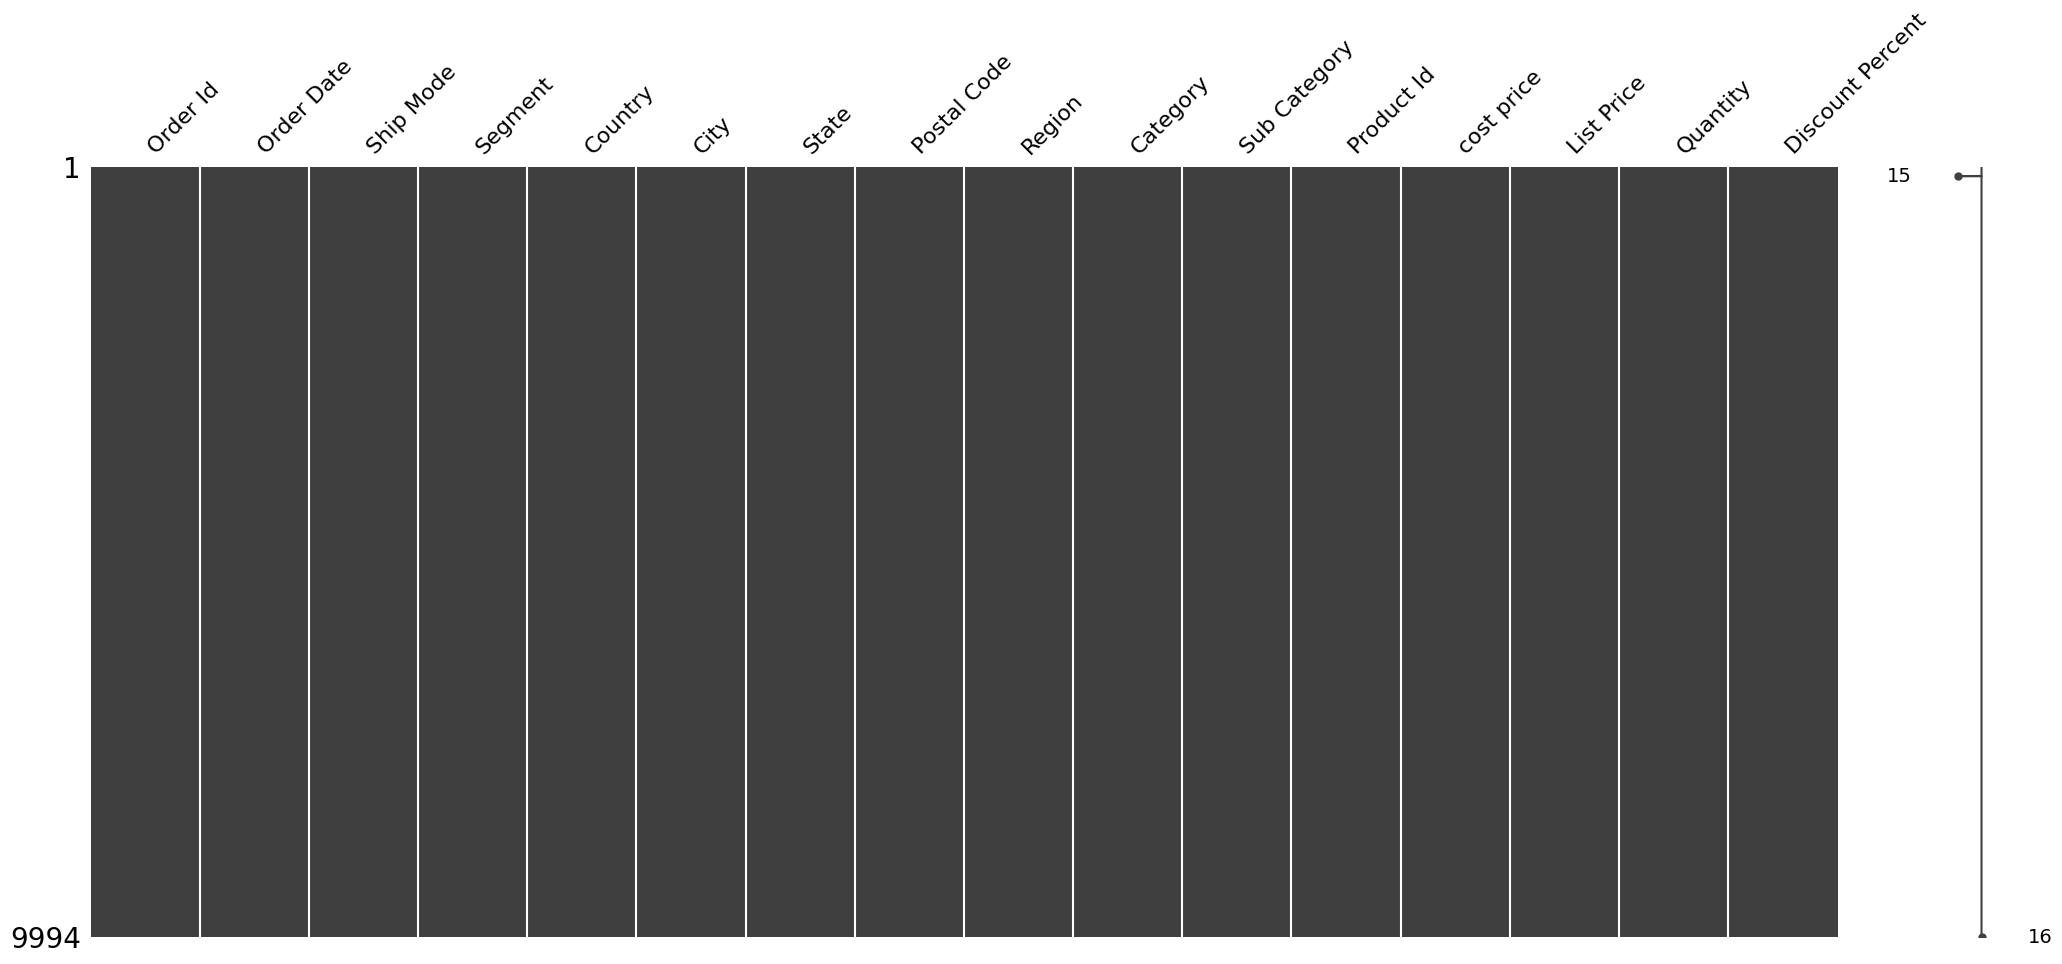

In [41]:
msno.matrix(df_orders)

<Axes: >

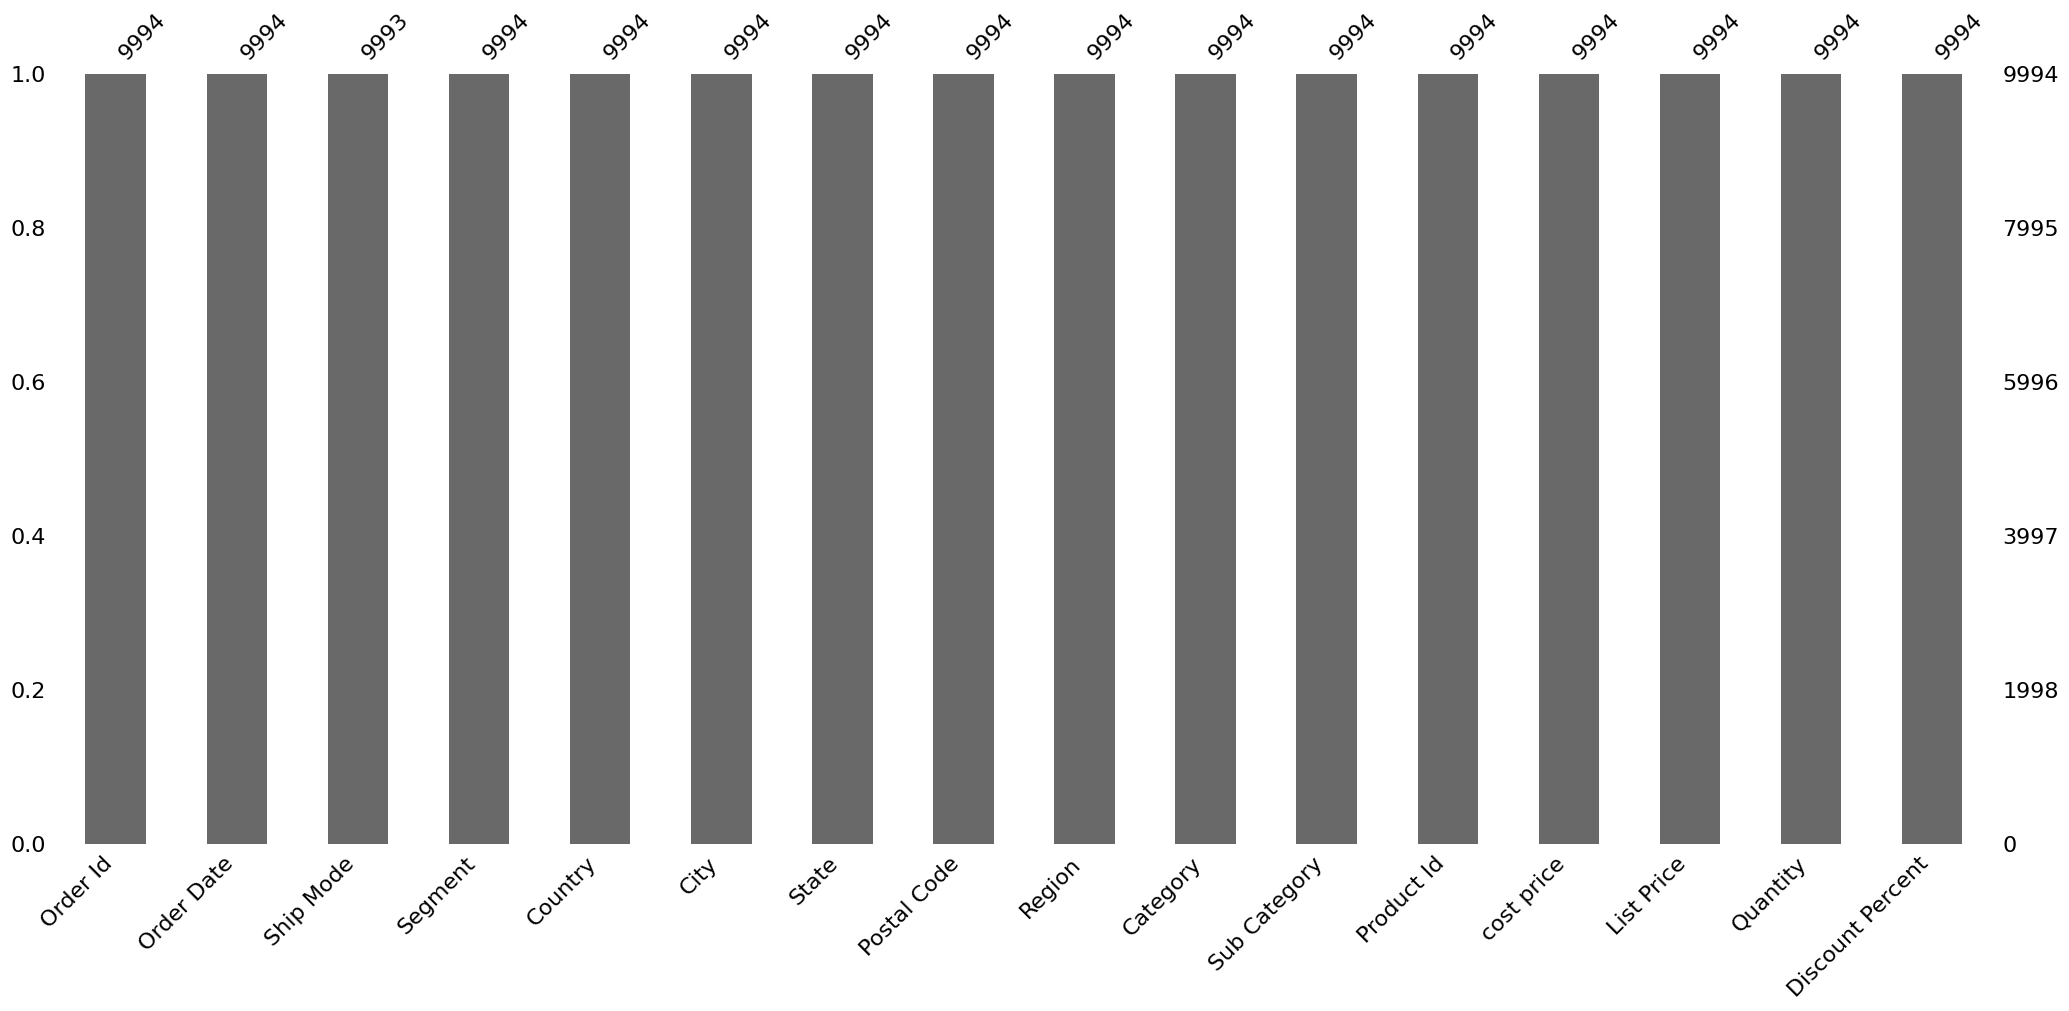

In [42]:
msno.bar(df_orders)

<Axes: >

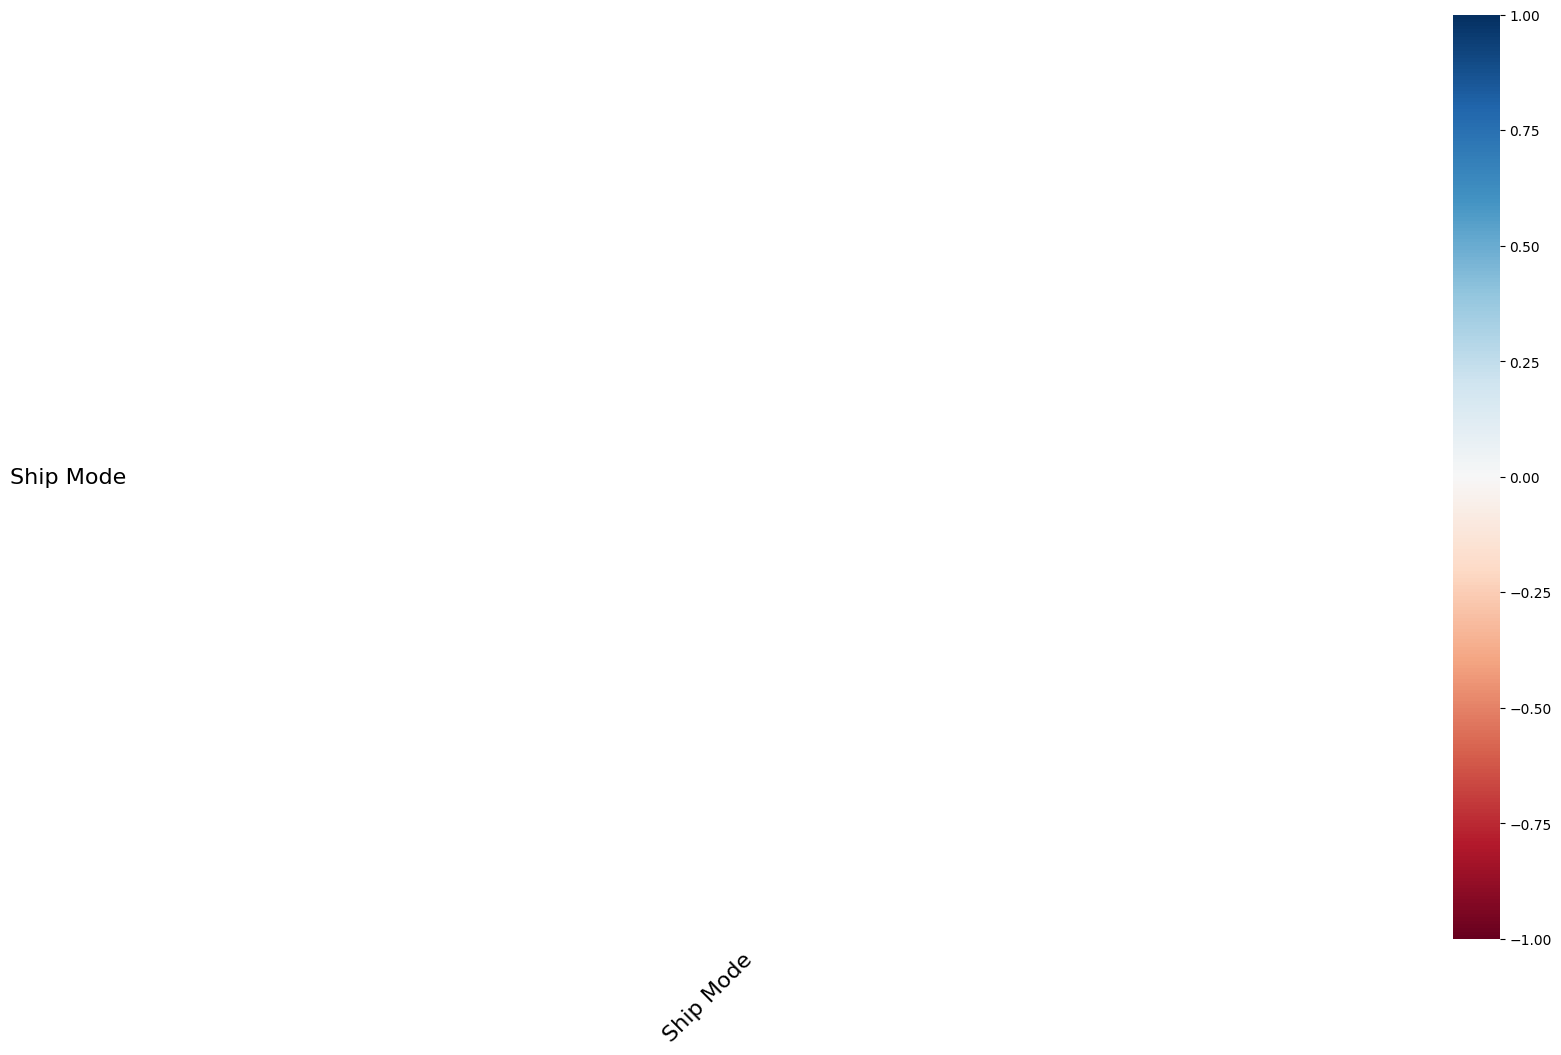

In [43]:
# Me ayuda a entender si hay alguna relación entre la existencia de na's en varias columnas
# al mismo tiempo
msno.heatmap(df_orders)

<Axes: >

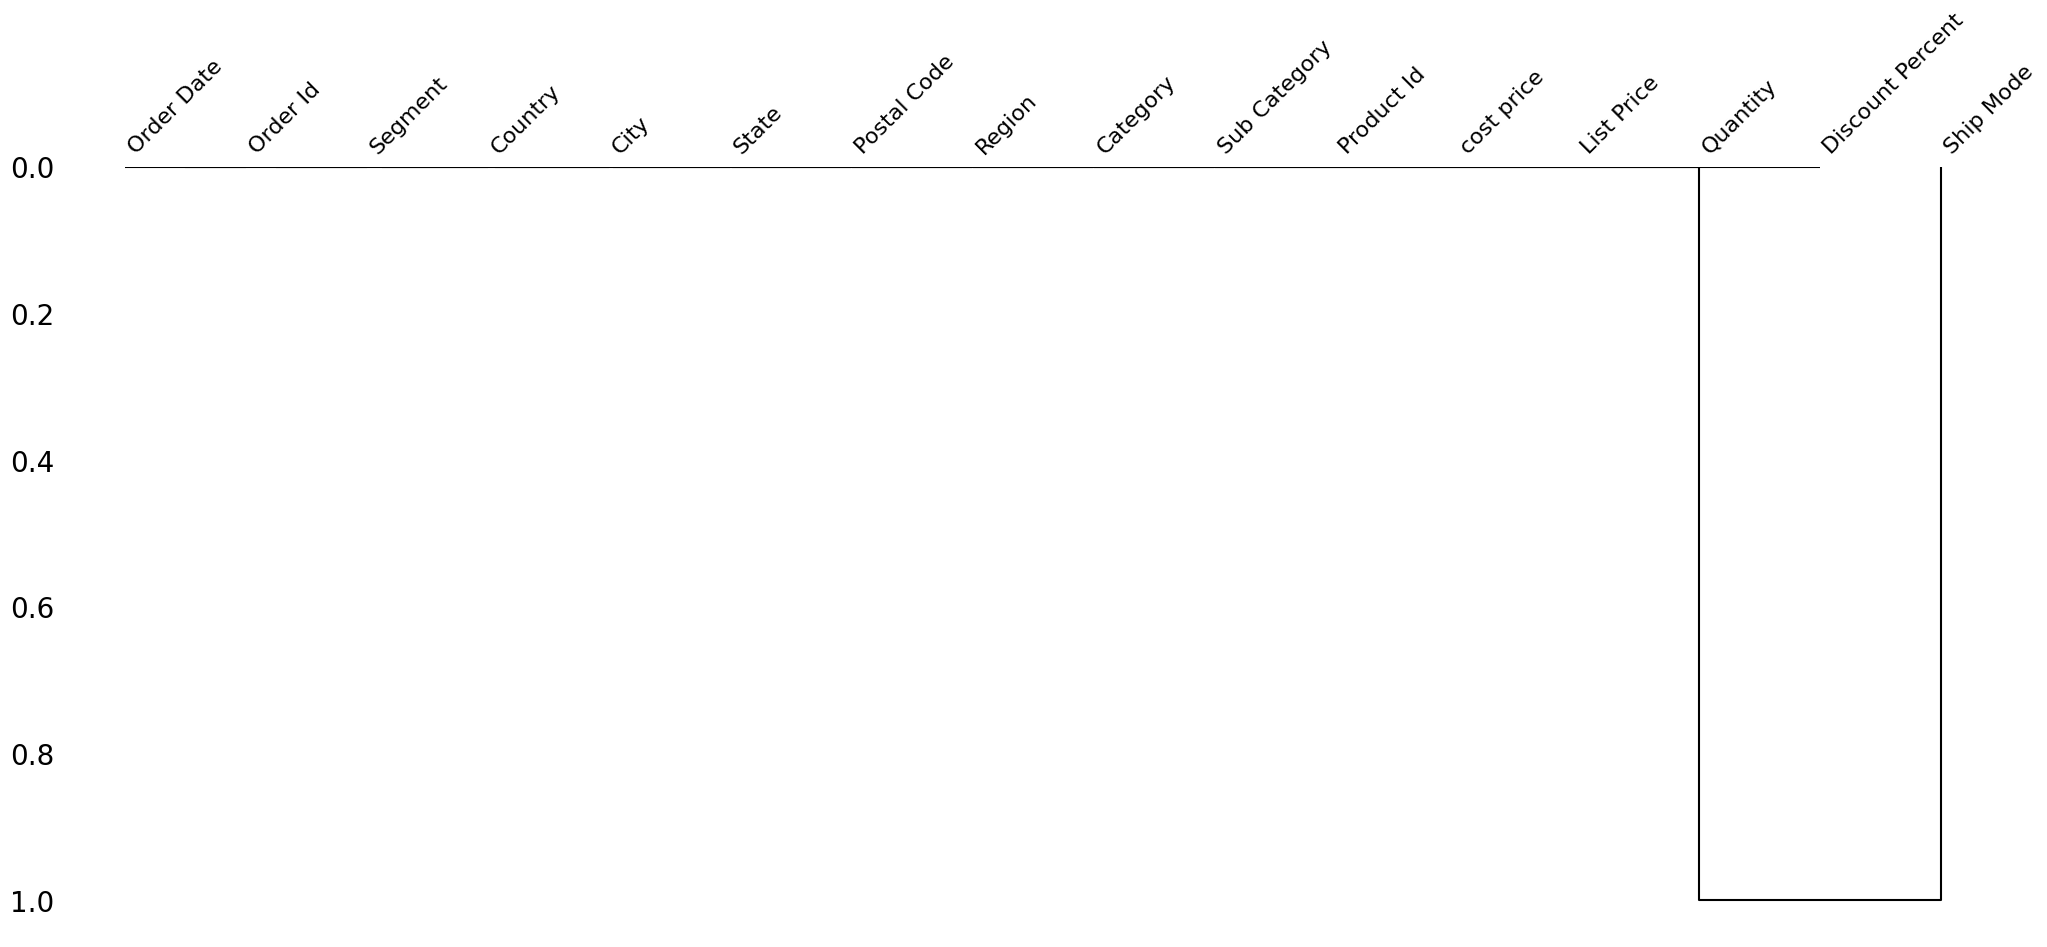

In [44]:
msno.dendrogram(df_orders)

Este dataframe esta muy completo. Veamos uno que está más incompleto.

In [45]:
df_coffee =pd.read_csv('coffee_ratings.csv')

In [46]:
# Demos un vistazo a este otro dataframe
df_coffee.head()

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


+ Vamos a meterle las funciones de visualización de datos faltantes

<Axes: >

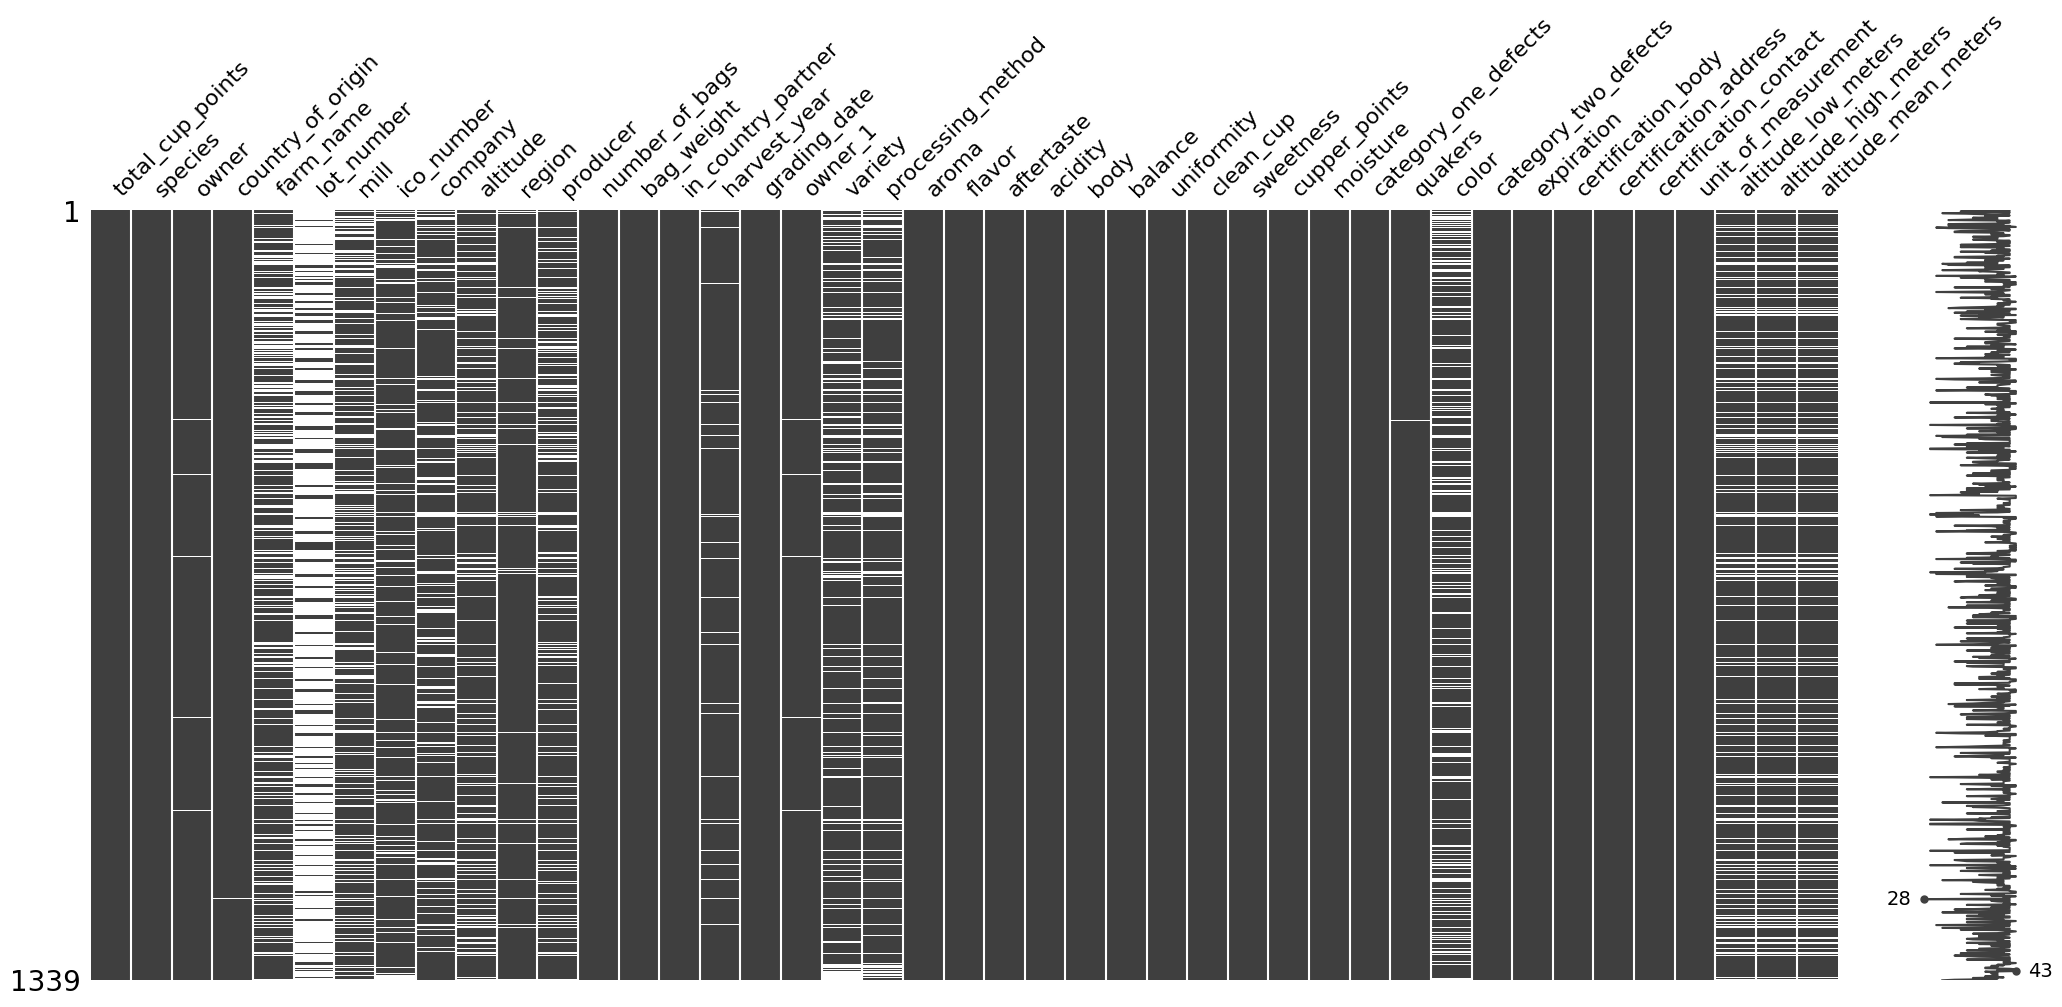

In [47]:
msno.matrix(df_coffee)

<Axes: >

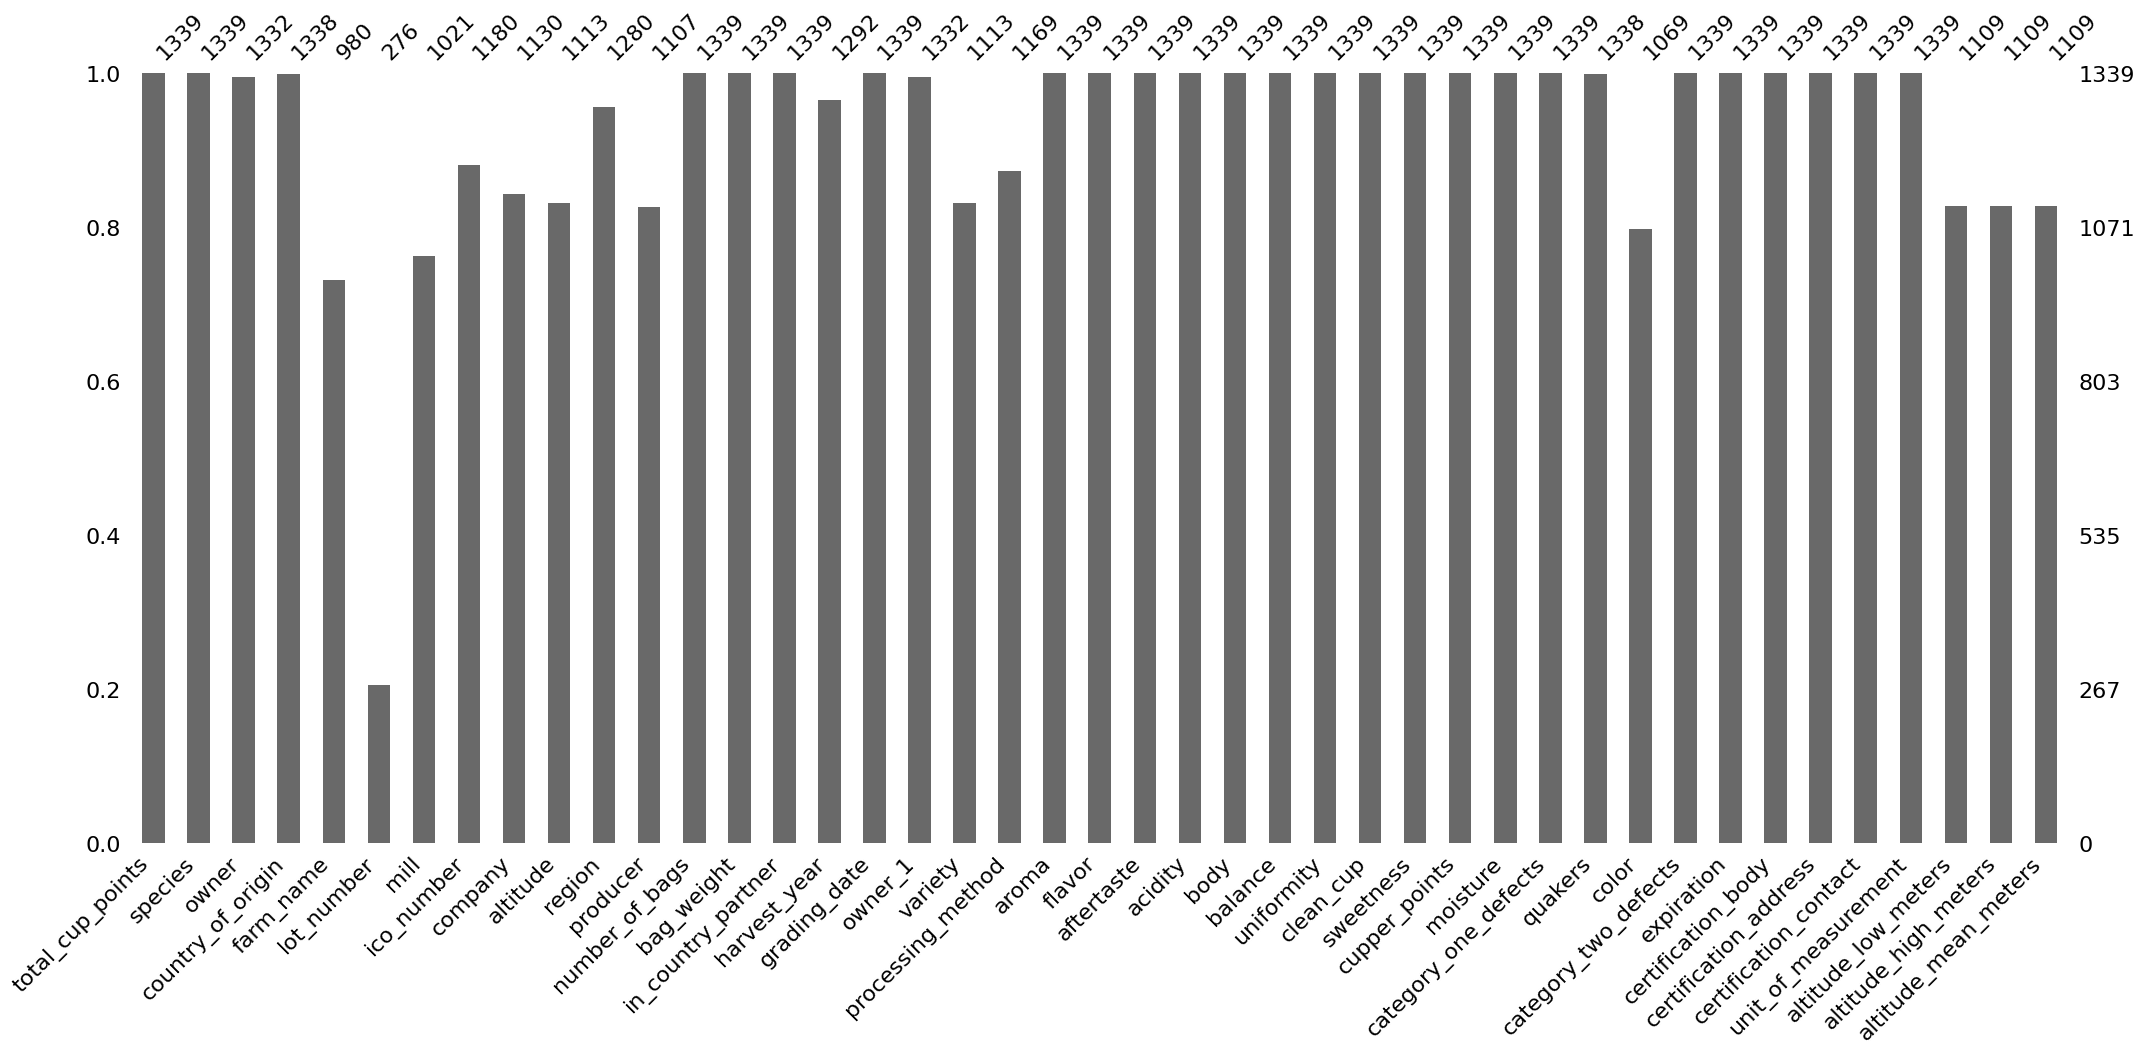

In [48]:
msno.bar(df_coffee)

<Axes: >

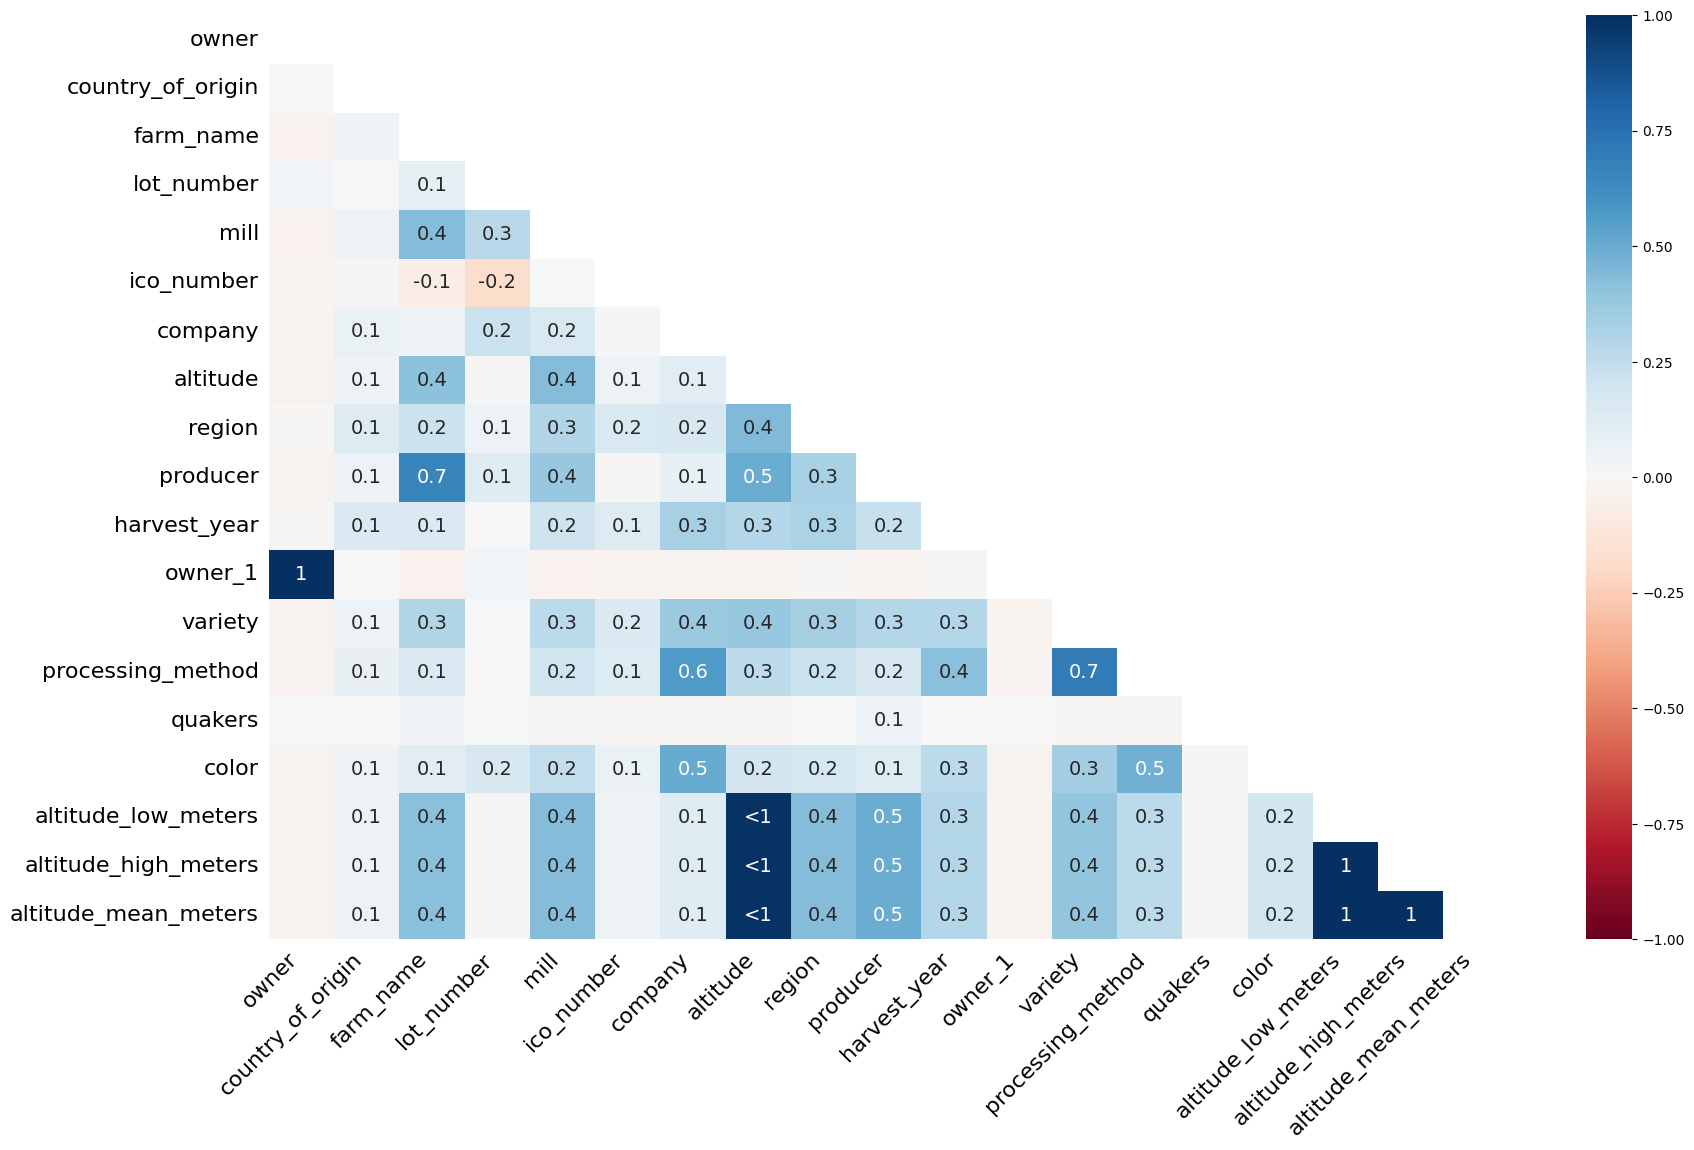

In [49]:
msno.heatmap(df_coffee)

<Axes: >

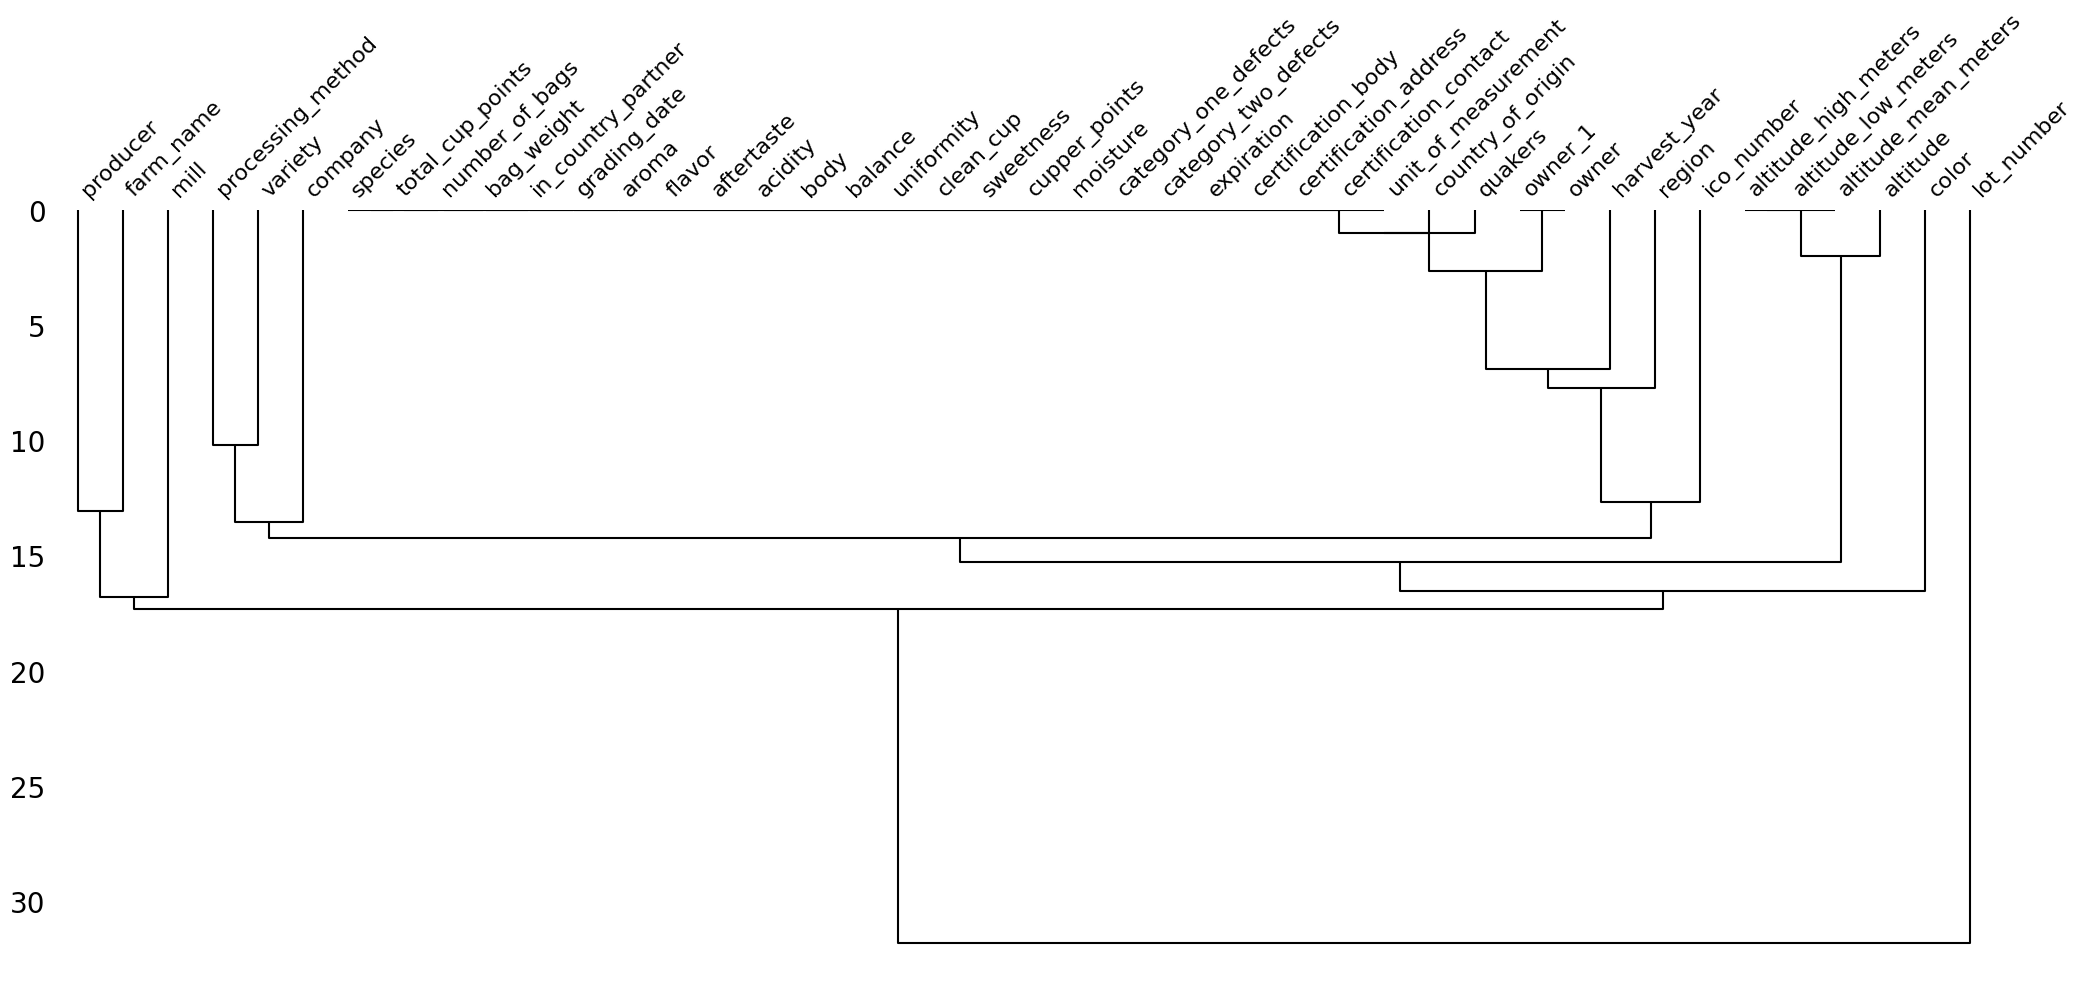

In [50]:
# Nos ayuda entender si hay alguna relación entre las columnas de renglones que tiene datos faltantes
msno.dendrogram(df_coffee)

+ Regresemos a nuestro dataset de orders

In [51]:
df_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent'],
      dtype='object')

In [52]:
df_orders['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'Not Available', 'unknown',
       'First Class', nan, 'Same Day'], dtype=object)

+ Aunque el nan nos queda claro (tanto a mí como a Python) que es un Not a Number. Hay valores que son strings 'Not Available' y 'unknown', que aunque toman esos valores en realidad se deben entender como nan's
+ Le tengo que hacer saber a Python que 'Not Available' y 'unknown' en realidad tmb son nan's
+ Esto se puede hacer desde la lectura del csv

In [53]:
#na_values=['Not Available','unknown']
# cuando te encuentres un 'Not Available' o un 'unknown' en realidad quiero que lo interpretes como nan
df_orders = pd.read_csv('orders.csv', na_values=['Not Available','unknown'])

In [54]:
# Cómo quedó la columna con esta nueva codificación
df_orders['Ship Mode'].unique()

array(['Second Class', 'Standard Class', nan, 'First Class', 'Same Day'],
      dtype=object)

+ ¿Qué pasa si metemos este dataset codificado mejor en las funciones de visualización de nan's?

<Axes: >

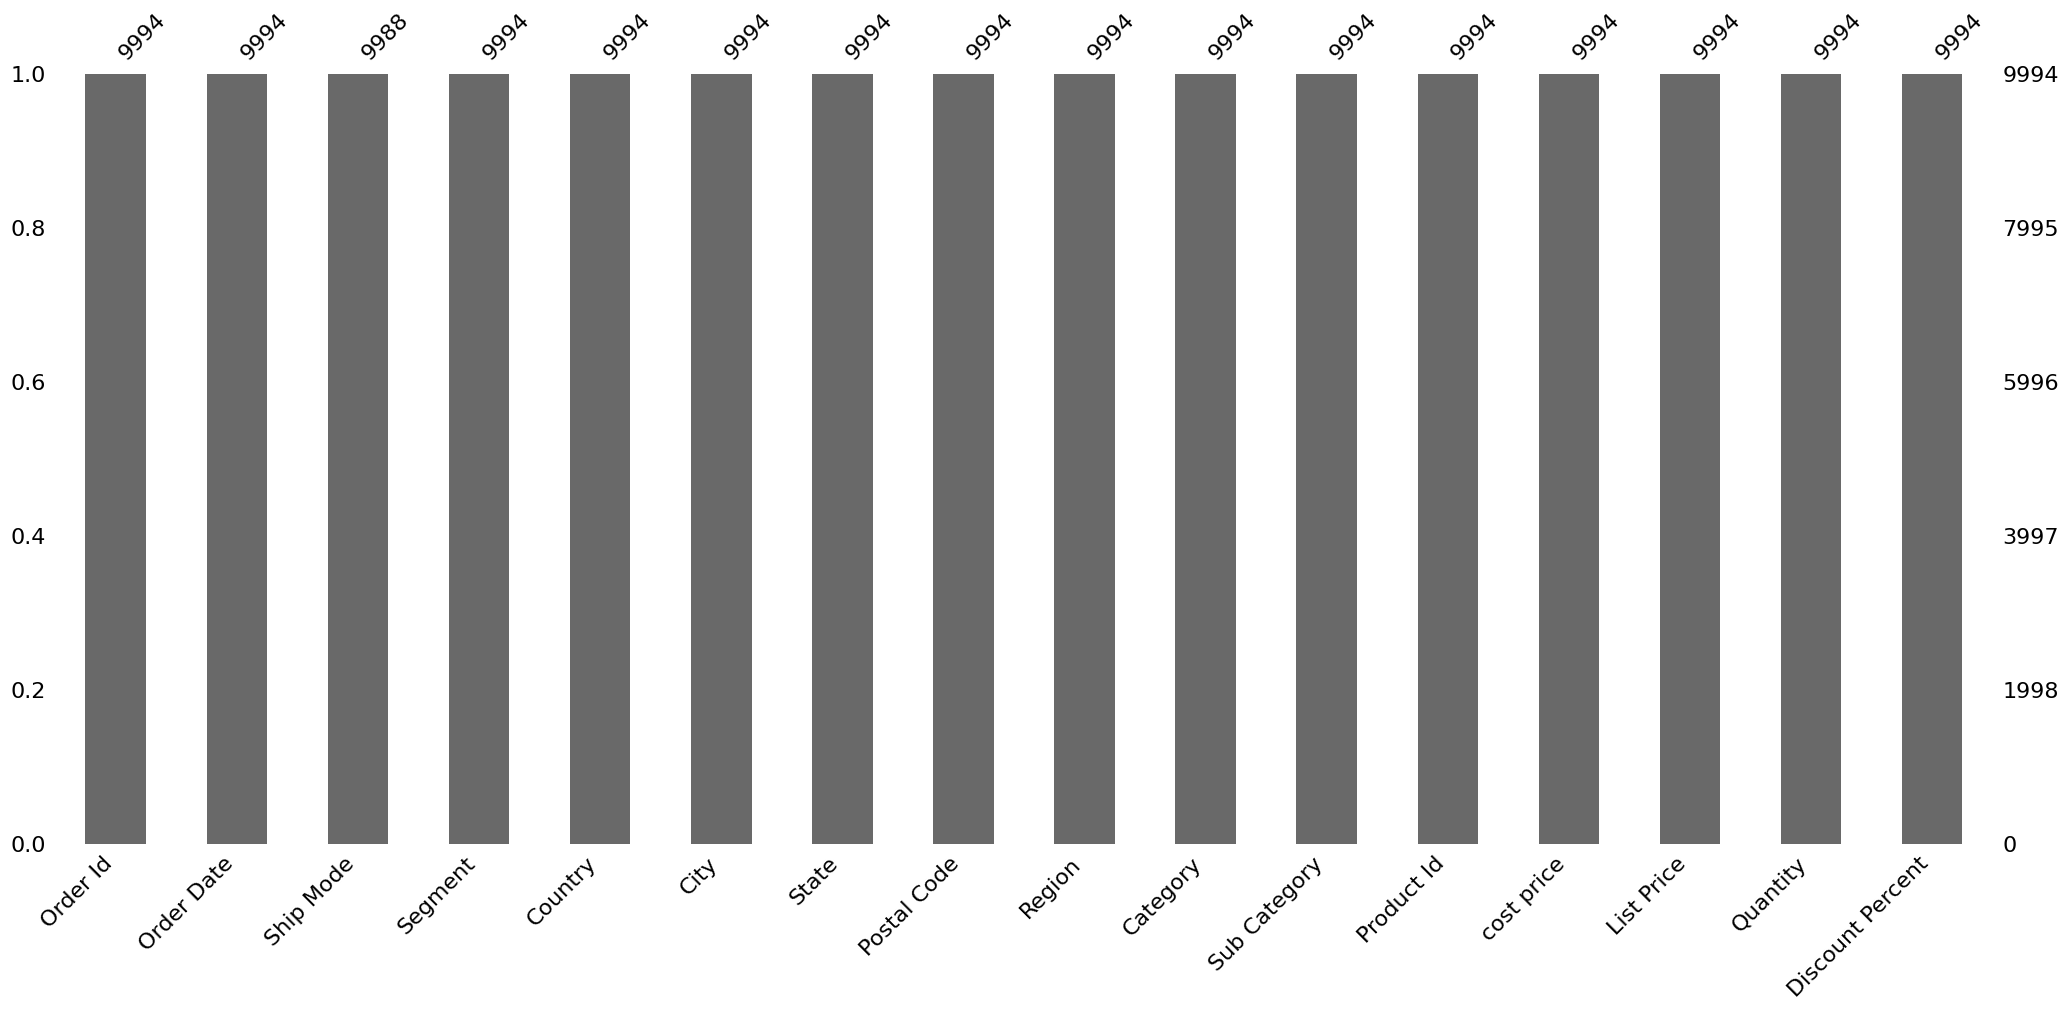

In [55]:
msno.bar(df_orders)

Pasamos de 1 nan a 6 nan's. Pero esto en dataframes reales del día a día es común
+ Que se codifique en nan como otro valor
+ Hay bases tan sucias que 999 significa nan

+ Recuérdese que una caractarística importante de los DataFrames (tanto los de Python como los de R) es que sus columnas tiene nombre.

+ Y ese nombre es importante, nos ayuda a seleccionar columnas por nombre y no por índice.

+ Esto quiere decir, que se intenta que los nombres de las columnas tengan un formato bonito para tirar código

In [56]:
df_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent'],
      dtype='object')

+ Los nombres de las columnas tienen espacios, mayúsculas y minúsculas. Nos gustaría que tuvieran un mejor formato para tirar código

In [57]:
df_orders.rename(columns={'Order Id':'order_id', 'City':'city'})

,order_id,Order Date,Ship Mode,Segment,Country,city,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,FUR-FU-10001889,30,30,3,4
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,FUR-FU-10000747,70,90,2,4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,TEC-PH-10003645,220,260,2,2
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,OFF-PA-10004041,30,30,4,3


In [58]:
# Lo primero que hago es pasar a minúsculas todos los nombres de las columnas
df_orders.columns = df_orders.columns.str.lower()

In [59]:
df_orders.head()

,order id,order date,ship mode,segment,country,city,state,postal code,region,category,sub category,product id,cost price,list price,quantity,discount percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [60]:
# Lo siguiente que me gustaría sería que los espacios en blanco los cambiaras por guiones bajos
df_orders.columns = df_orders.columns.str.replace(' ','_')

In [61]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


+ Intentemos tirar código así: mi_columna.funcion

+ En vez de asó `Mi columna toda horrible`.funcion

+ Ambas sintaxis funcionan pero la segunda es poco amigable para la persona que tira código

In [62]:
# Vamos a ver un poquito de la estructura del dataframe
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          9994 non-null   int64 
 1   order_date        9994 non-null   object
 2   ship_mode         9988 non-null   object
 3   segment           9994 non-null   object
 4   country           9994 non-null   object
 5   city              9994 non-null   object
 6   state             9994 non-null   object
 7   postal_code       9994 non-null   int64 
 8   region            9994 non-null   object
 9   category          9994 non-null   object
 10  sub_category      9994 non-null   object
 11  product_id        9994 non-null   object
 12  cost_price        9994 non-null   int64 
 13  list_price        9994 non-null   int64 
 14  quantity          9994 non-null   int64 
 15  discount_percent  9994 non-null   int64 
dtypes: int64(6), object(10)
memory usage: 1.2+ MB


Una vez que ya nos hicimos info de alguna API, un csv, un xlsx, una tabla de SQL y ya la tenemos en formato DataFrame, el mundo es nuestro

In [63]:
# Crear un nueva columna usando tras columnas
# Creo una nueva columna que se llama 'discount' que queremos que indique la cantidad monetaria del descuento
df_orders['discount'] = df_orders['list_price']*df_orders['discount_percent']

In [64]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,discount
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,520
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,2190
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,50
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,1920
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,100


In [65]:
# La columna 'discount_percent' está en porcentaje y no en decimal
df_orders['discount'] = df_orders['list_price']*df_orders['discount_percent']/100

In [66]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,discount
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,5.2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,21.9
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,19.2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,1.0


In [67]:
# Vamos a crear otras dos nuevas columnas
df_orders['sale_price'] = df_orders['list_price'] - df_orders['discount']
df_orders['profit'] = df_orders['sale_price'] - df_orders['cost_price']

In [68]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,discount,sale_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,5.2,254.8,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,21.9,708.1,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,0.5,9.5,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,19.2,940.8,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,1.0,19.0,-1.0


In [69]:
# Podríamos darle formato de fecha a la columna 'order_date'
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'],format="%Y-%m-%d")

In [70]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,discount,sale_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,5.2,254.8,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,21.9,708.1,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,0.5,9.5,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,19.2,940.8,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,1.0,19.0,-1.0


In [71]:
# Pareciera que no pasó nada pero sí pasó
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          9994 non-null   int64         
 1   order_date        9994 non-null   datetime64[ns]
 2   ship_mode         9988 non-null   object        
 3   segment           9994 non-null   object        
 4   country           9994 non-null   object        
 5   city              9994 non-null   object        
 6   state             9994 non-null   object        
 7   postal_code       9994 non-null   int64         
 8   region            9994 non-null   object        
 9   category          9994 non-null   object        
 10  sub_category      9994 non-null   object        
 11  product_id        9994 non-null   object        
 12  cost_price        9994 non-null   int64         
 13  list_price        9994 non-null   int64         
 14  quantity          9994 n

In [72]:
# Si quisiera eliminar algunas columnas
df_orders.drop(columns=['list_price','cost_price','discount_percent'])

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,quantity,discount,sale_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,2,5.2,254.8,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,3,21.9,708.1,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,2,0.5,9.5,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,5,19.2,940.8,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,2,1.0,19.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,2023-02-18,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,FUR-FU-10001889,3,1.2,28.8,-1.2
9990,9991,2023-03-17,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,FUR-FU-10000747,2,3.6,86.4,16.4
9991,9992,2022-08-07,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,TEC-PH-10003645,2,5.2,254.8,34.8
9992,9993,2022-11-19,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,OFF-PA-10004041,4,0.9,29.1,-0.9


In [73]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,discount,sale_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,5.2,254.8,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,21.9,708.1,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,0.5,9.5,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,19.2,940.8,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,1.0,19.0,-1.0


In [74]:
# Con esta sintaxis (inplace=True) se aplica la operación y se modifica el objeto al mismo tiempo
df_orders.drop(columns=['list_price','cost_price','discount_percent'], inplace=True)

In [75]:
df_orders.head()

,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,quantity,discount,sale_price,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,2,5.2,254.8,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,3,21.9,708.1,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,2,0.5,9.5,-0.5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,5,19.2,940.8,160.8
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,2,1.0,19.0,-1.0
